# K-Nearest Neighbors — From-Scratch NumPy Implementation

This notebook implements the KNN algorithm described in `notes.md` directly in NumPy, with no scikit-learn model involved:

1. Build a small toy 2D dataset with two visually separable classes.
2. Compute pairwise Euclidean distances from a query point to every training point.
3. Take the `k` nearest neighbors and predict by majority vote.
4. Visualize the resulting decision boundary.
5. Sanity-check the from-scratch predictions against `sklearn.neighbors.KNeighborsClassifier` on the same data.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

rng = np.random.default_rng(42)

%matplotlib inline


## 1) Toy 2D dataset

Two blobs of points in 2D, each labeled with its own class (0 or 1).


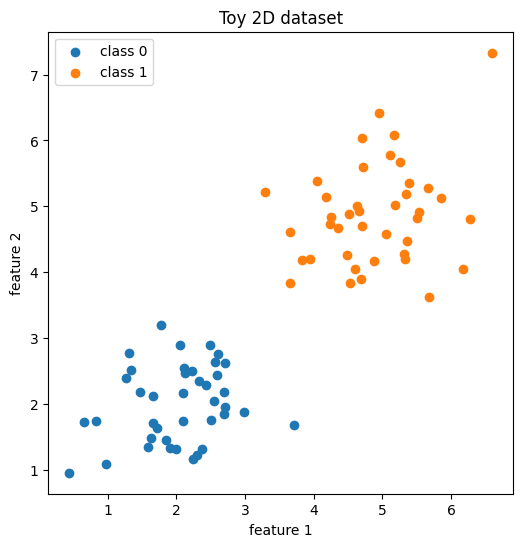

In [2]:
n_per_class = 40

class0 = rng.normal(loc=[2, 2], scale=0.8, size=(n_per_class, 2))
class1 = rng.normal(loc=[5, 5], scale=0.8, size=(n_per_class, 2))

X_train = np.vstack([class0, class1])
y_train = np.array([0] * n_per_class + [1] * n_per_class)

plt.figure(figsize=(6, 6))
plt.scatter(class0[:, 0], class0[:, 1], color="tab:blue", label="class 0")
plt.scatter(class1[:, 0], class1[:, 1], color="tab:orange", label="class 1")
plt.xlabel("feature 1")
plt.ylabel("feature 2")
plt.title("Toy 2D dataset")
plt.legend()
plt.show()


## 2) Pairwise Euclidean distances

For a query point $x$, compute the Euclidean distance (Section 4 of `notes.md`) to every training point in one vectorized NumPy call:

$$d(x, p_i) = \sqrt{\sum_{j=1}^n (x_j - p_{i,j})^2}$$


In [3]:
def pairwise_euclidean_distances(query_points, train_points):
    """Euclidean distance from every query point to every training point.

    query_points: (n_queries, n_features)
    train_points: (n_train, n_features)
    returns: (n_queries, n_train) distance matrix
    """
    query_points = np.atleast_2d(query_points)
    diffs = query_points[:, np.newaxis, :] - train_points[np.newaxis, :, :]
    return np.sqrt(np.sum(diffs ** 2, axis=-1))


# sanity check on a couple of points
sample_distances = pairwise_euclidean_distances(X_train[:2], X_train)
print("Distance matrix shape:", sample_distances.shape)
print(sample_distances[0, :5])


Distance matrix shape: (2, 80)
[0.         1.62406946 1.81675134 0.59603336 0.29753183]


## 3) k-nearest selection + majority vote

Sort the distances for each query point, take the indices of the `k` smallest, and predict the majority label among those `k` neighbors.


In [4]:
def knn_predict(X_query, X_train, y_train, k):
    """Predict labels for X_query using k-nearest-neighbors majority vote."""
    distances = pairwise_euclidean_distances(X_query, X_train)  # (n_query, n_train)
    nearest_idx = np.argsort(distances, axis=1)[:, :k]          # (n_query, k)

    predictions = np.empty(X_query.shape[0], dtype=y_train.dtype)
    for i, neighbor_idx in enumerate(nearest_idx):
        neighbor_labels = y_train[neighbor_idx]
        vote = Counter(neighbor_labels.tolist()).most_common(1)[0][0]
        predictions[i] = vote
    return predictions


# quick check: classify a point that should clearly belong to class 0,
# and one that should clearly belong to class 1
query = np.array([[2.0, 2.0], [5.0, 5.0]])
preds = knn_predict(query, X_train, y_train, k=5)
print("Predictions for", query.tolist(), "->", preds.tolist())


Predictions for [[2.0, 2.0], [5.0, 5.0]] -> [0, 1]


## 4) Decision boundary visualization

Classify every point on a fine grid covering the data to visualize the resulting decision boundary for a chosen `k`.


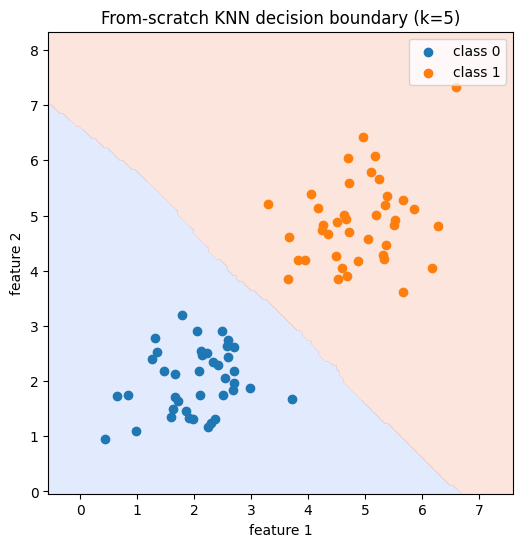

In [5]:
def plot_decision_boundary(X_train, y_train, k, ax, resolution=150):
    x_min, x_max = X_train[:, 0].min() - 1, X_train[:, 0].max() + 1
    y_min, y_max = X_train[:, 1].min() - 1, X_train[:, 1].max() + 1
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, resolution),
        np.linspace(y_min, y_max, resolution),
    )
    grid_points = np.column_stack([xx.ravel(), yy.ravel()])
    grid_preds = knn_predict(grid_points, X_train, y_train, k=k).reshape(xx.shape)

    ax.contourf(xx, yy, grid_preds, alpha=0.25, cmap="coolwarm", levels=1)
    ax.scatter(X_train[y_train == 0, 0], X_train[y_train == 0, 1], color="tab:blue", label="class 0")
    ax.scatter(X_train[y_train == 1, 0], X_train[y_train == 1, 1], color="tab:orange", label="class 1")
    ax.set_title(f"From-scratch KNN decision boundary (k={k})")
    ax.set_xlabel("feature 1")
    ax.set_ylabel("feature 2")
    ax.legend()


fig, ax = plt.subplots(figsize=(6, 6))
plot_decision_boundary(X_train, y_train, k=5, ax=ax)
plt.show()


## 5) Sanity check against `sklearn.neighbors.KNeighborsClassifier`

The from-scratch predictions should match scikit-learn's implementation exactly on the same data and `k`, confirming the manual distance-compute/sort/vote pipeline is correct.


In [6]:
from sklearn.neighbors import KNeighborsClassifier

k = 5
sklearn_model = KNeighborsClassifier(n_neighbors=k)
sklearn_model.fit(X_train, y_train)

# compare on a held-out grid of random query points
test_queries = rng.uniform(low=X_train.min(axis=0) - 1, high=X_train.max(axis=0) + 1, size=(200, 2))

scratch_preds = knn_predict(test_queries, X_train, y_train, k=k)
sklearn_preds = sklearn_model.predict(test_queries)

agreement = np.mean(scratch_preds == sklearn_preds)
print(f"Agreement between from-scratch KNN and sklearn KNeighborsClassifier: {agreement:.4f}")
assert agreement == 1.0, "From-scratch predictions should match sklearn exactly for the same k and metric."


Agreement between from-scratch KNN and sklearn KNeighborsClassifier: 1.0000


## Takeaway

- The entire KNN algorithm is three vectorized steps: compute all pairwise distances, sort to find the k smallest, and take a majority vote among their labels — there is no training-time optimization anywhere in the pipeline.
- The from-scratch predictions agree exactly with `sklearn.neighbors.KNeighborsClassifier` on the same toy dataset and `k`, confirming the manual implementation is correct.
- The decision boundary plot shows the qualitative shape described in `notes.md`: a boundary that follows local structure rather than committing to a single global line.
